/Users/thijsvanschaik/Desktop/school/Uni/year4_last_hopefully/thesis_yehes/starting_fr_fr/BayesianRLunderUncertainty/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


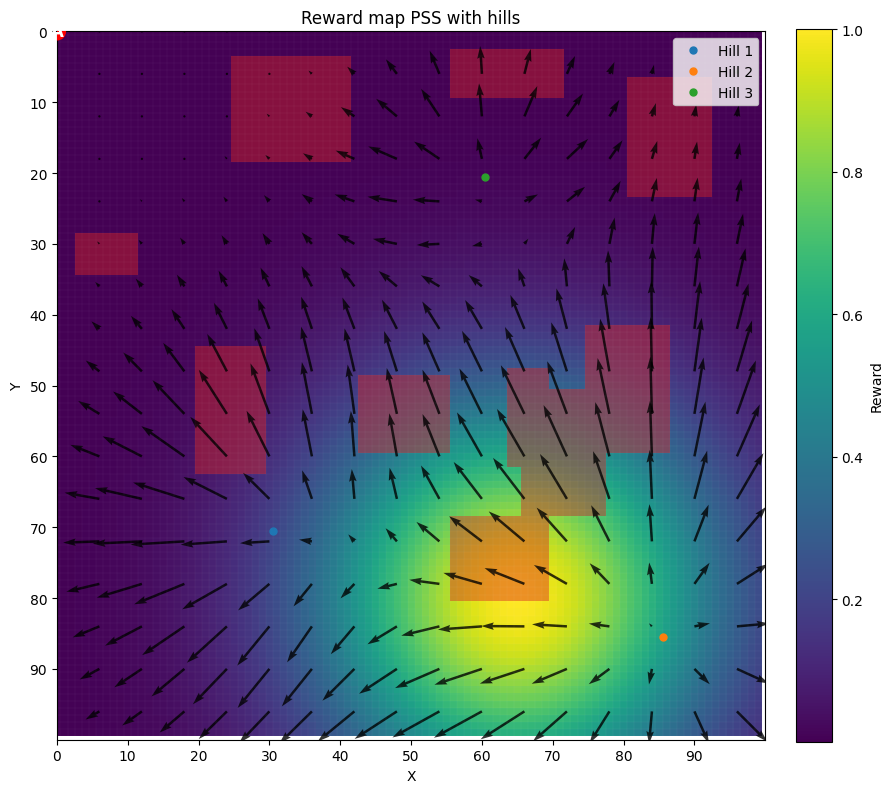

In [1]:
from pathlib import Path
from matplotlib.patches import Circle, Patch
import matplotlib.pyplot as plt
import sys
import numpy as np
from scipy.stats import multivariate_normal
import torch

start_state = (0, 0)

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',    
        va='center',
        zorder=4
    )


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_combined(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plot_agent(start_state, ax=ax)
plt.show()

x_top, y_top = env.reward_gaussian_mean
states_visited = {start_state: 1}

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

In [ ]:
from src.q_learning import QLearningAgent

EPISODES = 5000
MAX_STEPS = 200
ALPHA = 0.3
GAMMA = 0.9
EPSILON = 1
EPSILON_DECAY = 0.9995
MIN_EPSILON = 0.2

def square_keep_sign(n):
    if n >= 0:
        return n ** 2
    else:
        return -(n ** 2)

def distance_to_goal(state, top=(x_top, y_top)):
    x, y = state
    return np.sqrt((x - top[0]) ** 2 + (y - top[1]) ** 2)

agent = QLearningAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON, 
                       epsilon_decay=EPSILON_DECAY, min_epsilon=MIN_EPSILON)

loss_f= lambda s, s_prime, env: square_keep_sign(distance_to_goal(s) - distance_to_goal(s_prime)) - 10

train_x, train_y, unsafe_counts = agent.train(start_state, episodes=EPISODES, max_steps=MAX_STEPS, loss_f=loss_f)


Training Episodes: 100%|██████████| 5000/5000 [06:09<00:00, 13.55it/s]


/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_34912/4267497286.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)


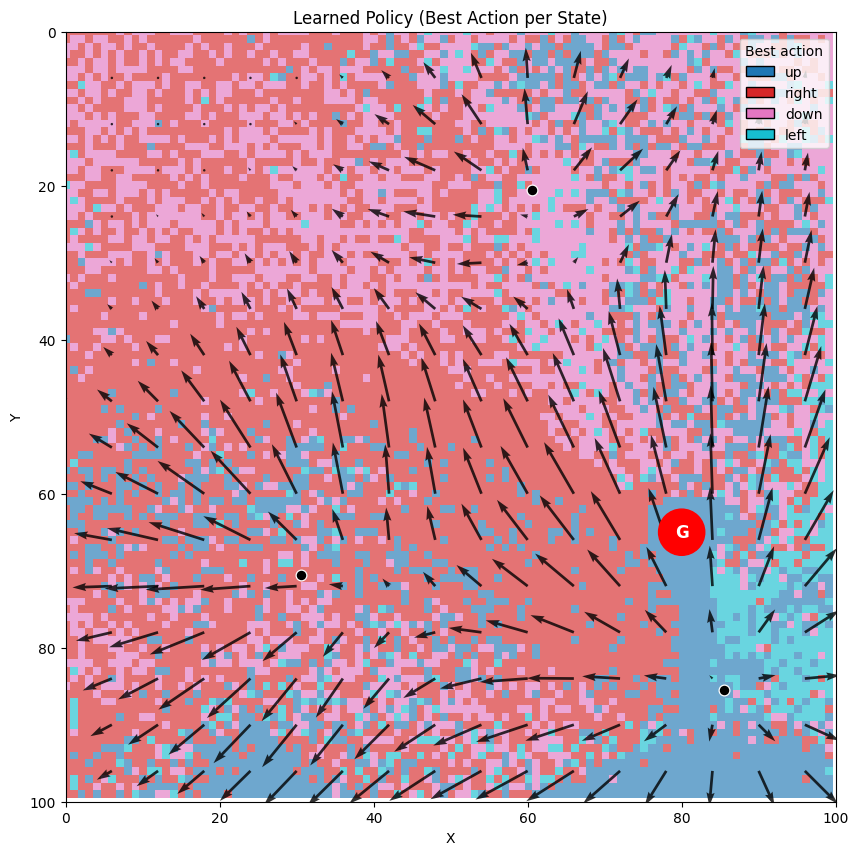

In [101]:
def plot_policy(Q, env, ax=None):
    max_x, max_y = env.grid_shape
    policy_grid = np.argmax(Q, axis=2)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    
    # Color each state by its best action (no policy arrows).
    # Use top-origin to match the rest of the environment visualizations (y=0 at top).
    action_cmap = plt.cm.get_cmap('tab10', 4)
    im = ax.imshow(
        policy_grid.T,
        cmap=action_cmap,
        origin='upper',
        interpolation='nearest',
        vmin=-0.5,
        vmax=3.5,
        alpha=0.65
    )
    
    # Keep hill vectors and hill-top markers on top.
    env.plot_hills(ax=ax, color='black')
    for top, *_ in env.hill_tops:
        tx, ty = top
        ax.scatter(tx + 0.5, ty + 0.5, s=60, c='black', edgecolors='white', linewidths=0.9, zorder=6)

    goal = Circle((x_top, y_top), radius=3, color='red', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        x_top, y_top, 'G',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 
    
    
    action_labels = ['up', 'right', 'down', 'left']
    legend_handles = [
        Patch(facecolor=action_cmap(i), edgecolor='black', label=label)
        for i, label in enumerate(action_labels)
    ]
    ax.legend(handles=legend_handles, title='Best action', loc='upper right', frameon=True)
    
    ax.set_title('Learned Policy (Best Action per State)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

def plot_run(Q, env, start_state, max_steps=1000, num_runs=1, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    env.plot_combined(ax=ax)
    env.plot_hills(ax=ax, color='black')

    plot_agent(start_state, ax=ax)
    

    goal = Circle((x_top, y_top), radius=2, color='green', zorder=3)
    ax.add_patch(goal)

    # Draw white 'G' in the center
    ax.text(
        x_top, y_top, 'G',
        color='white',
        fontsize=8,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    ) 

    colors = plt.cm.get_cmap('tab10', max(num_runs, 1))
    for run_idx in range(num_runs):
        s = start_state
        trajectory = [s]

        for _ in range(max_steps):
            x, y = s
            a_index = np.argmax(Q[x, y, :])
            a = list(actions.values())[a_index]
            s = env.transition(s, a)
            trajectory.append(s)

            if agent.distance_to_goal(s) < 5:
                break

        traj_x, traj_y = zip(*trajectory)
        ax.plot(
            traj_x, traj_y,
            marker='o',
            color=colors(run_idx),
            label=f'Run {run_idx + 1}' if num_runs > 1 else 'Agent Trajectory'
        )
    ax.legend()
    ax.set_title("Agent Trajectory Following Learned Q-values")
    plt.show()

fig, ax = plt.subplots(figsize=(10, 10))

Q = agent.get_q_values()

plot_policy(Q, env, ax=ax)
plt.show()


/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_34912/2529305707.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', max(num_runs, 1))


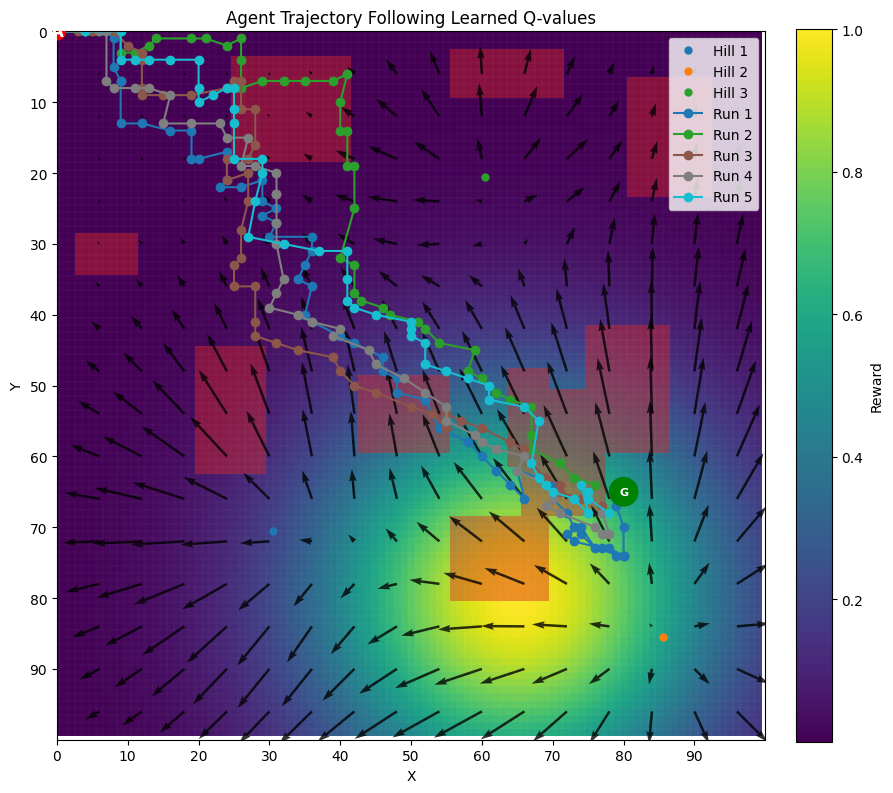

In [4]:

plot_run(Q, env, start_state, max_steps=MAX_STEPS, num_runs=5)

Iter 10/50 - Loss X: 5.222, Loss Y: 6.383
Iter 20/50 - Loss X: 4.710, Loss Y: 6.033
Iter 30/50 - Loss X: 4.618, Loss Y: 5.834
Iter 40/50 - Loss X: 4.538, Loss Y: 5.734
Iter 50/50 - Loss X: 4.497, Loss Y: 5.675


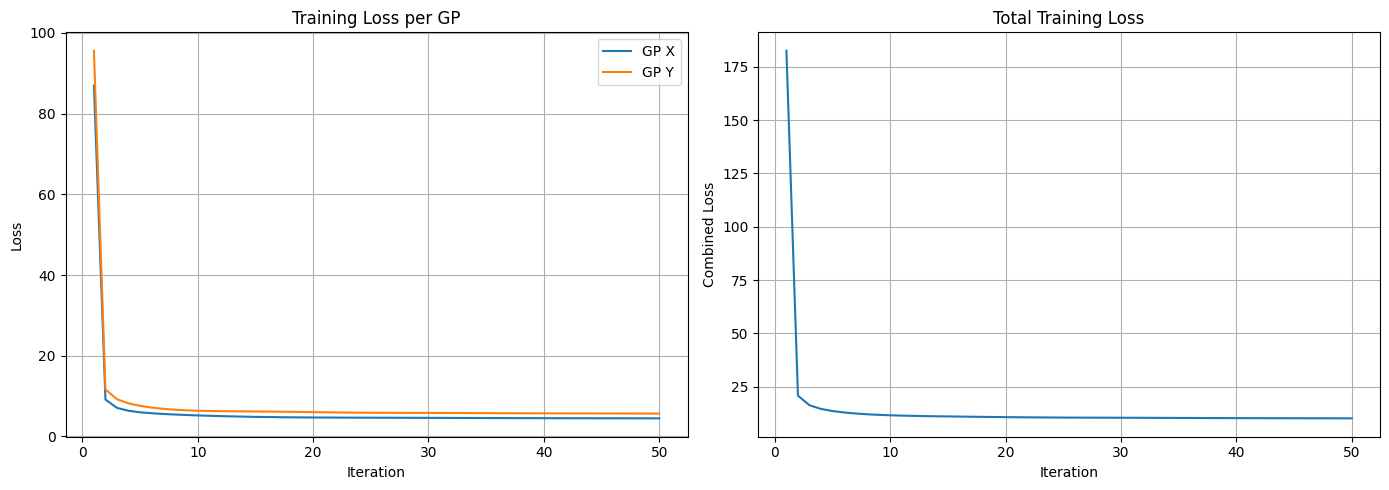

In [5]:
from src.GP import BoTorchDualSingleTaskGP

starting_pos = [(50, 50), (20, 20), (80, 80), (20, 80), (80, 20)]

train_x, train_y, states_visited = BoTorchDualSingleTaskGP.get_random_train_data(env=env, start_positions=starting_pos)
model = BoTorchDualSingleTaskGP(train_x, train_y)
losses_x, losses_y = model.fit(training_iterations=50, lr=0.1, verbose=True)

# Plot loss curves
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(range(1, len(losses_x) + 1), losses_x, label='GP X')
axs[0].plot(range(1, len(losses_y) + 1), losses_y, label='GP Y')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training Loss per GP')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(range(1, len(losses_x) + 1), [lx + ly for lx, ly in zip(losses_x, losses_y)])
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Combined Loss')
axs[1].set_title('Total Training Loss')
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# takes very long
def plot_ll_heatmap(model, 
                    start_positions, 
                    env, 
                    actions, 
                    grid_resolution=100, 
                    n_samples_per_cell=50, 
                    threshold=-10,
                    red_max=-2,
                    ax=None
                    ):
    """
    Plot log-likelihood heatmap for BoTorchDualSingleTaskGP model.
    Uses model.predict() to get mean and covariance.
    """
    from matplotlib.colors import LinearSegmentedColormap

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                # Get GP prediction using new predict method
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()  # (2,)
                pred_cov = pred_cov  # (2, 2)
                
                # Sample from real environment and compute log prob under GP
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    # Create distribution and compute log prob
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        # If covariance is not positive definite, use diagonal approximation
                        log_prob = -10  # penalty for numerical issues
                    
                    total_log_prob += log_prob
            
            # Average log likelihood for this cell
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Create custom colormap: viridis for values <= threshold, red gradient for > threshold
    vmin, vmax = log_likelihood_map.min(), log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Plot main heatmap with viridis for values below threshold
    plot_data_viridis = np.where(log_likelihood_map <= threshold, log_likelihood_map, np.nan)
    im = ax.imshow(plot_data_viridis, cmap='viridis', origin='lower', 
                extent=[0, 100, 0, 100], aspect='equal', vmin=vmin, vmax=threshold)

    # Create red gradient colormap (light red to dark red)
    reds_cmap = LinearSegmentedColormap.from_list('custom_reds', ['#ffcccc', '#ff0000', '#8b0000'])

    # Plot red gradient for values > threshold
    plot_data_red = np.where(log_likelihood_map > threshold, log_likelihood_map, np.nan)
    im_red = ax.imshow(plot_data_red, cmap=reds_cmap, origin='lower', 
                    extent=[0, 100, 0, 100], aspect='equal', vmin=threshold, vmax=red_max)

    # Add colorbars
    plt.colorbar(im, ax=ax, label='Log Likelihood (poor)', location='left', pad=0.12)
    plt.colorbar(im_red, ax=ax, label='Log Likelihood (good)', location='right')

    # Mark training start positions
    for pos in start_positions:
        ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'GP Model Log Likelihood Heatmap\n(White stars = training start positions)')

    good_mask = log_likelihood_map > threshold
    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    print(f"  Cells with LL > {threshold}: {good_mask.sum()} / {log_likelihood_map.size}")
    
    return ax, log_likelihood_map


def plot_ll_heatmap_simple(model, 
                           start_positions, 
                           env, 
                           actions, 
                           grid_resolution=100, 
                           n_samples_per_cell=50, 
                           cmap='RdYlGn',
                           vmin=None,
                           vmax=None,
                           ax=None,
                           show_hills=True,
                           show_start_positions=True,
                           colorbar_label='Log Likelihood'
                           ):
    """
    Simple log-likelihood heatmap with single colormap and adjustable colors.
    
    Args:
        model: BoTorchDualSingleTaskGP model
        start_positions: list of (x, y) training start positions
        env: environment for sampling transitions
        actions: dict of action name -> action tuple
        grid_resolution: number of grid cells per axis
        n_samples_per_cell: samples per cell for LL estimation
        cmap: colormap name or LinearSegmentedColormap (e.g. 'viridis', 'RdYlGn', 'coolwarm')
        vmin: minimum value for colormap (None = auto)
        vmax: maximum value for colormap (None = auto)
        ax: matplotlib axes (creates new if None)
        show_hills: whether to overlay hill contours
        show_start_positions: whether to mark training start positions
        colorbar_label: label for the colorbar
    
    Returns:
        ax, log_likelihood_map
    """
    from matplotlib.colors import LinearSegmentedColormap

    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))

    model.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float64)
                pred_mean, pred_cov = model.predict(x_input)
                pred_mean = pred_mean.squeeze()
                
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float64)
                    
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        log_prob = -10
                    
                    total_log_prob += log_prob
            
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Use provided bounds or auto-detect
    plot_vmin = vmin if vmin is not None else log_likelihood_map.min()
    plot_vmax = vmax if vmax is not None else log_likelihood_map.max()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Single colormap for entire range
    im = ax.imshow(log_likelihood_map, cmap=cmap, origin='lower', 
                   extent=[0, 100, 0, 100], aspect='equal', 
                   vmin=plot_vmin, vmax=plot_vmax)

    plt.colorbar(im, ax=ax, label=colorbar_label)

    if show_start_positions:
        for pos in start_positions:
            ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    if show_hills:
        env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('GP Model Log Likelihood Heatmap')

    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    
    return ax, log_likelihood_map


def plot_visited_overlay(states_visited, ax=None, color='blue', min_alpha=0.1, max_alpha=0.9, show_colorbar=True):
    """
    Plot a transparent overlay showing how often states were visited.
    Alpha scales with visit count - more visits = more opaque.
    
    Args:
        states_visited: dict mapping (x, y) tuples to visit counts
        ax: matplotlib axes to overlay on
        color: single color for all visited states (name or hex)
        min_alpha: minimum alpha for least visited states
        max_alpha: maximum alpha for most visited states
        show_colorbar: whether to add a colorbar showing visit counts
    """
    from matplotlib.colors import to_rgba
    
    grid_size = 100
    visit_counts = np.zeros((grid_size, grid_size))
    
    for state, count in states_visited.items():
        x, y = state
        if 0 <= x < grid_size and 0 <= y < grid_size:
            visit_counts[y, x] = count
    
    # Get max visits for normalization
    max_visits = visit_counts.max()
    if max_visits == 0:
        return ax
    
    # Create RGBA image: same color everywhere, alpha scales with visit count
    base_color = to_rgba(color)[:3]  # Get RGB without alpha
    
    # Normalize visit counts to [0, 1]
    normalized_counts = visit_counts / max_visits
    
    # Scale alpha: 0 visits -> 0 alpha, max visits -> max_alpha
    # For visited cells, scale between min_alpha and max_alpha
    alpha_map = np.where(visit_counts > 0, 
                         min_alpha + normalized_counts * (max_alpha - min_alpha),
                         0)
    
    # Create RGBA array
    rgba_image = np.zeros((grid_size, grid_size, 4))
    rgba_image[:, :, 0] = base_color[0]  # R
    rgba_image[:, :, 1] = base_color[1]  # G
    rgba_image[:, :, 2] = base_color[2]  # B
    rgba_image[:, :, 3] = alpha_map      # A (scaled by visit count)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.imshow(rgba_image, origin='lower', extent=[0, 100, 0, 100], aspect='equal')
    
    if show_colorbar:
        # Create a fake ScalarMappable for the colorbar to show visit counts
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize as mplNormalize
        
        # Create a colormap that goes from transparent to solid color
        from matplotlib.colors import LinearSegmentedColormap
        cmap_alpha = LinearSegmentedColormap.from_list(
            'alpha_scale', 
            [(base_color[0], base_color[1], base_color[2], min_alpha),
             (base_color[0], base_color[1], base_color[2], max_alpha)]
        )
        sm = cm.ScalarMappable(cmap=cmap_alpha, norm=mplNormalize(vmin=1, vmax=max_visits))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Visit Count', shrink=0.6)
    
    return ax

Processed row 10/50
Processed row 20/50
Processed row 30/50
Processed row 40/50
Processed row 50/50

Log likelihood statistics:
  Min: -24.61
  Max: -2.87
  Mean: -6.34


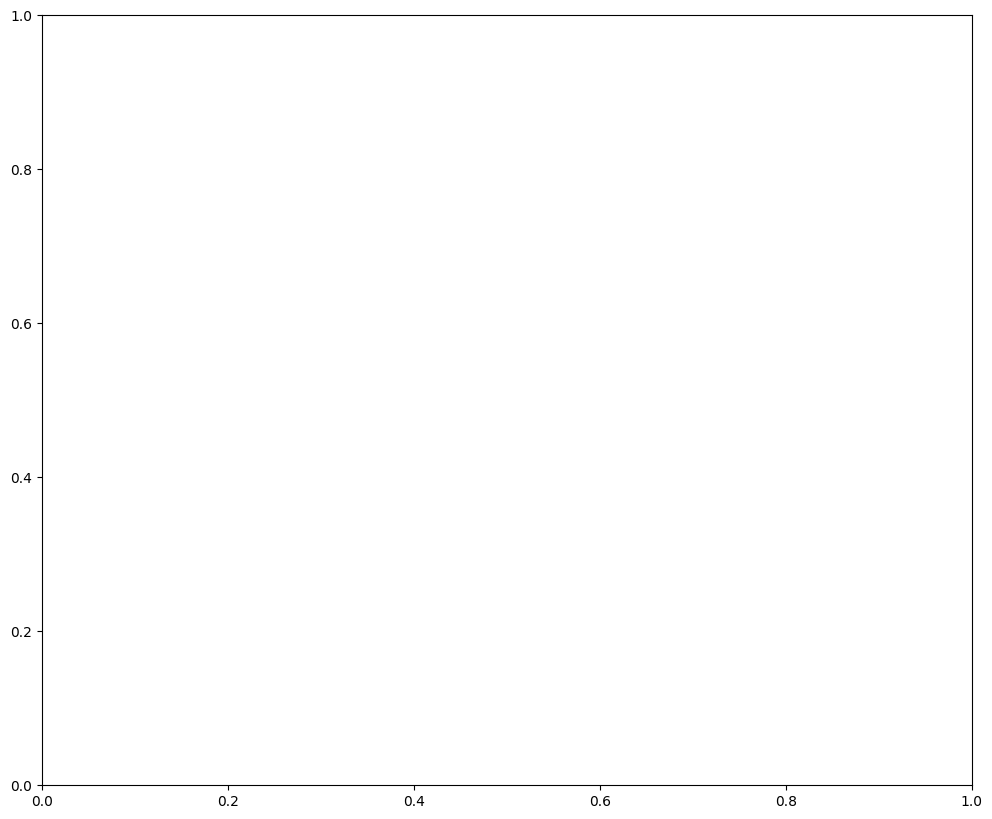

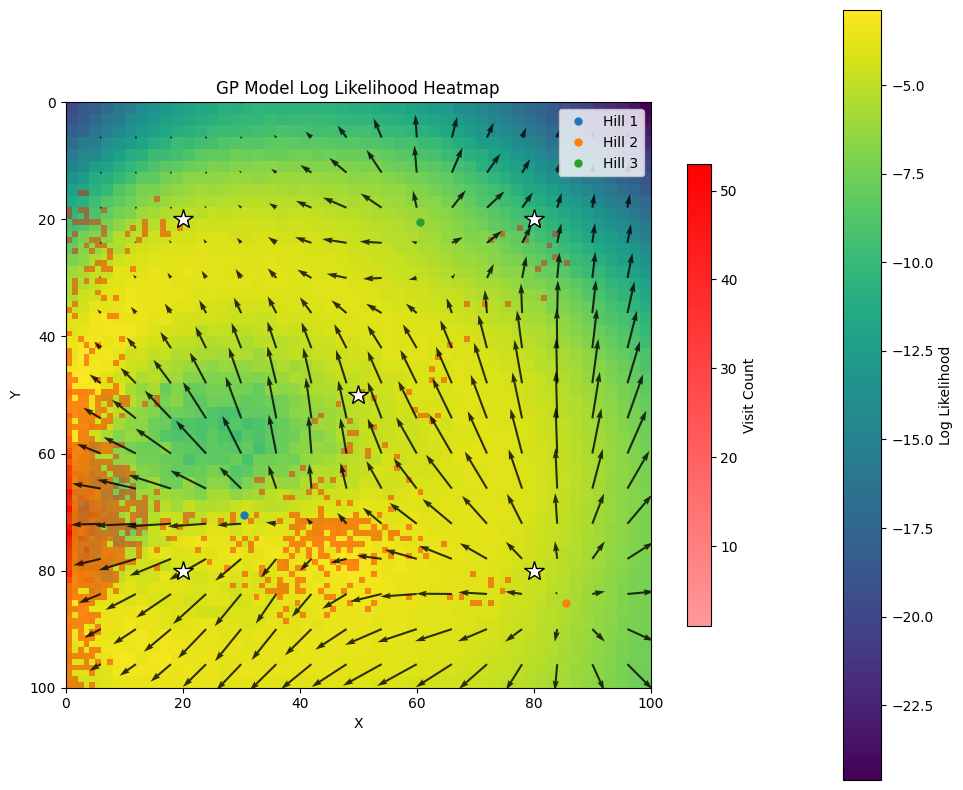

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
ax, ll_map = plot_ll_heatmap_simple(
    model, starting_pos, env, actions,
    grid_resolution=50, 
    n_samples_per_cell=20,
    cmap='viridis'
)
plot_visited_overlay(states_visited, ax, color='red', max_alpha=1.0, min_alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# max_x, max_y = env.grid_shape

# pred_mean_with_policy = np.zeros((max_x, max_y, 2), dtype=np.float64)      # [x, y, mean_x, mean_y]
# pred_cov_with_policy  = np.zeros((max_x, max_y, 2, 2), dtype=np.float64)   # [x, y, cov(2x2)]

# action_list = list(actions.values())

# for x in range(max_x):
#     for y in range(max_y):
#         best_action_index = np.argmax(Q[x, y, :])
#         best_action = action_list[best_action_index]

#         x_input = torch.tensor([[x, y, best_action[0], best_action[1]]], dtype=torch.float64)
#         pred_mean, pred_cov = model.predict(x_input)

#         mean_np = pred_mean.squeeze(0).detach().cpu().numpy()   # shape (2,)
#         cov_np  = pred_cov.detach().cpu().numpy()               # shape (2,2)

#         pred_mean_with_policy[x, y] = mean_np
#         pred_cov_with_policy[x, y] = cov_np

def policy_accounted_action_estimates(Q, model, actions, env=env, action_rank=0, action_num=None):
    max_x, max_y = env.grid_shape

    pred_mean_with_policy = np.zeros((max_x, max_y, 2), dtype=np.float64)      # [x, y, mean_x, mean_y]
    pred_cov_with_policy  = np.zeros((max_x, max_y, 2, 2), dtype=np.float64)   # [x, y, cov(2x2)]

    action_list = list(actions.values())

    for x in range(max_x):
        for y in range(max_y):
            # allow for selecting the 2nd best action (action_rank=1) or 3rd best (action_rank=2)
            if action_num is None:
                sorted_indices = np.argsort(Q[x, y, :])[::-1]
                selected_action_index = sorted_indices[action_rank]
                selected_action = action_list[selected_action_index]
            else:
                selected_action = action_list[action_num]


            x_input = torch.tensor([[x, y, selected_action[0], selected_action[1]]], dtype=torch.float64)
            pred_mean, pred_cov = model.predict(x_input)

            mean_np = pred_mean.squeeze(0).detach().cpu().numpy()   # shape (2,)
            cov_np  = pred_cov.detach().cpu().numpy()               # shape (2,2)

            pred_mean_with_policy[x, y] = mean_np
            pred_cov_with_policy[x, y] = cov_np

    return pred_mean_with_policy, pred_cov_with_policy

In [ ]:
for x in range(100):
    for y in range(100):
        sorted_indices = np.argsort(Q[x, y, :])[::-1]
        selected_action_index = sorted_indices[0]
        selected_action = list(actions.values())[selected_action_index]

print(selected_action)

(0, -1)


In [78]:
from scipy.stats import norm

def transition_prob_policy(state, next_state, pred_mean_with_policy, pred_cov_with_policy, grid_shape=(100, 100)):
    x, y = state
    nx, ny = next_state
    max_x, max_y = grid_shape
    
    # Bounds check for current state
    if not (0 <= x < max_x and 0 <= y < max_y):
        return 0.0
    
    # Bounds check for next state (must be valid cell)
    if not (0 <= nx < max_x and 0 <= ny < max_y):
        return 0.0
    
    # Get predicted mean and covariance for this state
    mean = pred_mean_with_policy[x, y]      # shape (2,): [mean_x, mean_y]
    cov = pred_cov_with_policy[x, y]        # shape (2, 2): diagonal covariance
    
    # Extract standard deviations (covariance is diagonal)
    std_x = np.sqrt(cov[0, 0])
    std_y = np.sqrt(cov[1, 1])
    
    mean_x, mean_y = mean[0], mean[1]
    
    # Define cell boundaries for x-coordinate
    # Cell 0 absorbs everything < 0.5 (due to clipping + rounding)
    # Cell max_x-1 absorbs everything >= max_x-1 - 0.5
    if nx == 0:
        x_lo, x_hi = -np.inf, 0.5
    elif nx == max_x - 1:
        x_lo, x_hi = nx - 0.5, np.inf
    else:
        x_lo, x_hi = nx - 0.5, nx + 0.5
    
    # Define cell boundaries for y-coordinate
    if ny == 0:
        y_lo, y_hi = -np.inf, 0.5
    elif ny == max_y - 1:
        y_lo, y_hi = ny - 0.5, np.inf
    else:
        y_lo, y_hi = ny - 0.5, ny + 0.5
    
    # Compute probability mass using CDF differences
    # P(x in [lo, hi]) = Φ((hi - μ)/σ) - Φ((lo - μ)/σ)
    p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)
    p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)
    
    # Since x and y are independent (diagonal covariance), joint probability is product
    return p_x * p_y



# vectorized version for multiple states and next states
def calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env):
    # from The Probabilistic Model Checking Landscape by Joost-Pieter Katoen
    max_x, max_y = env.grid_shape

    N = len(S)
    M = len(S)

    pred_mean_with_policy = np.array(pred_mean_with_policy)  
    pred_cov_with_policy = np.array(pred_cov_with_policy)   

    means = pred_mean_with_policy[S[:,0], S[:,1]]   # (N,2)
    covs  = pred_cov_with_policy[S[:,0], S[:,1]]    # (N,2,2)

    mean_x = means[:, 0][:, None]   # (N,1)
    mean_y = means[:, 1][:, None]

    std_x = np.sqrt(covs[:, 0, 0])[:, None]
    std_y = np.sqrt(covs[:, 1, 1])[:, None]

    nx = S[:, 0][None, :]   # (1,M)
    ny = S[:, 1][None, :]

    x_lo = np.where(nx == 0, -np.inf,
                    np.where(nx == max_x-1, nx - 0.5, nx - 0.5))

    x_hi = np.where(nx == 0, 0.5,
                    np.where(nx == max_x-1, np.inf, nx + 0.5))

    y_lo = np.where(ny == 0, -np.inf,
                    np.where(ny == max_y-1, ny - 0.5, ny - 0.5))

    y_hi = np.where(ny == 0, 0.5,
                    np.where(ny == max_y-1, np.inf, ny + 0.5))

    p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)

    p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)

    full_P_est_pi = p_x * p_y

    # resize 10000x10000 to 100x100x100x100 for easy indexing
    P_pi_overline = full_P_est_pi.reshape(
        max_x, max_y, max_x, max_y
    )

    x = S_q[:, 0]
    y = S_q[:, 1]

    A = P_pi_overline[x[:, None], y[:, None], x[None, :], y[None, :]]

    qx = q[:, 0]
    qy = q[:, 1]

    b_ = P_pi_overline[x[:, None], y[:, None], qx[None, :], qy[None, :]].sum(axis=1)
    return A, b_

# total = 0.0

# for x in range(max_x):
#     for y in range(max_y):
#         total += transition_prob_policy((99,99), (x, y), pred_mean_with_policy, pred_cov_with_policy, grid_shape=(max_x, max_y))

# print(total)

In [10]:
# dp = np.array([[[None] for _ in range(max_x)]
#       for _ in range(max_y)])

# print(dp.shape)

# def x(state, q, pred_mean_with_policy=pred_mean_with_policy, pred_cov_with_policy=pred_cov_with_policy, grid_shape=(100, 100), dp=None):

#     s_x, s_y = state

#     if dp is None:
#         dp = {}

#     if (s_x, s_y) in dp:
#         return dp[s_x, s_y]

#     if (s_x, s_y) in q:
#         dp[s_x, s_y] = 1.0
#         return 1.0

#     value = 0.0
#     if (s_x, s_y) in q:
#         return 1.0
#     else:
#         value = 0.0
#         for i in range(grid_shape[0]):
#             for j in range(grid_shape[1]):
#                 if (i, j) in q:
#                     value += transition_prob_policy(state, 
#                                                     (i, j), 
#                                                     pred_mean_with_policy, 
#                                                     pred_cov_with_policy, 
#                                                     grid_shape=grid_shape)
#                 else:
#                     value += transition_prob_policy(state, 
#                                                     (i, j), 
#                                                     pred_mean_with_policy, 
#                                                     pred_cov_with_policy, 
#                                                     grid_shape=grid_shape) * x((i, j), q, pred_mean_with_policy, pred_cov_with_policy, grid_shape, dp)
                    
#     dp[s_x, s_y] = value

# for i in range(max_x):
#     for j in range(max_y):
#         if i==1 and j == 0:
#             print(f"Computing x for state ({i}, {j})...")
#         if i%10 == 0 and j == 0:
#             print(f"Computing x for state ({i}, {j})...")
#         x((i, j), states_visited, pred_mean_with_policy, pred_cov_with_policy, grid_shape=(max_x, max_y), dp=dp)


In [52]:
# from scipy.stats import norm
# import numpy as np

# S_q = np.array(np.argwhere(~env.unsafe_mask).tolist())
# q = np.array(np.argwhere(env.unsafe_mask).tolist())
# S = np.array([(s_x, s_y) for s_x in range(max_x) for s_y in range(max_y)])

# N = len(S)  # 10000
# M = len(S)  # 10000

# pred_mean_with_policy = np.array(pred_mean_with_policy)  # shape (100, 100, 2)
# pred_cov_with_policy = np.array(pred_cov_with_policy)    # shape (100, 100, 2, 2)

# means = pred_mean_with_policy[S[:,0], S[:,1]]   # (N,2)
# covs  = pred_cov_with_policy[S[:,0], S[:,1]]    # (N,2,2)

# mean_x = means[:, 0][:, None]   # (N,1)
# mean_y = means[:, 1][:, None]

# std_x = np.sqrt(covs[:, 0, 0])[:, None]
# std_y = np.sqrt(covs[:, 1, 1])[:, None]

# nx = S[:, 0][None, :]   # (1,M)
# ny = S[:, 1][None, :]

# x_lo = np.where(nx == 0, -np.inf,
#                 np.where(nx == max_x-1, nx - 0.5, nx - 0.5))

# x_hi = np.where(nx == 0, 0.5,
#                 np.where(nx == max_x-1, np.inf, nx + 0.5))

# y_lo = np.where(ny == 0, -np.inf,
#                 np.where(ny == max_y-1, ny - 0.5, ny - 0.5))

# y_hi = np.where(ny == 0, 0.5,
#                 np.where(ny == max_y-1, np.inf, ny + 0.5))

# p_x = norm.cdf(x_hi, loc=mean_x, scale=std_x) - norm.cdf(x_lo, loc=mean_x, scale=std_x)

# p_y = norm.cdf(y_hi, loc=mean_y, scale=std_y) - norm.cdf(y_lo, loc=mean_y, scale=std_y)

# full_P_est_pi = p_x * p_y

# print(full_P_est_pi.shape)

# print(full_P_est_pi)
# print(np.max(full_P_est_pi))

# P_pi_overline = full_P_est_pi.reshape(
#     max_x, max_y, max_x, max_y
# )

# print(P_pi_overline.shape)

(10000, 10000)
[[7.51949683e-010 3.62414940e-009 1.84457558e-008 ... 0.00000000e+000
  0.00000000e+000 0.00000000e+000]
 [2.23762254e-010 1.23717051e-009 7.04032026e-009 ... 0.00000000e+000
  0.00000000e+000 0.00000000e+000]
 [1.64817174e-012 1.27144297e-011 9.76101537e-011 ... 0.00000000e+000
  0.00000000e+000 0.00000000e+000]
 ...
 [3.43683779e-123 3.04643585e-121 2.60192699e-119 ... 1.50872590e-003
  1.31351867e-003 3.90298165e-003]
 [2.60481024e-122 2.20024091e-120 1.79327711e-118 ... 1.57678304e-003
  1.42459887e-003 4.79618764e-003]
 [2.17535542e-121 1.74879824e-119 1.35850541e-117 ... 1.60396837e-003
  1.50148291e-003 5.74580479e-003]]
0.5397304776713896
(100, 100, 100, 100)


In [55]:
# x = S_q[:, 0]
# y = S_q[:, 1]

# A = P_pi_overline[x[:, None], y[:, None], x[None, :], y[None, :]]

# qx = q[:, 0]
# qy = q[:, 1]

# b_ = P_pi_overline[x[:, None], y[:, None], qx[None, :], qy[None, :]].sum(axis=1)


# # solve (A - I)x = -b
# x = np.linalg.solve(A - np.eye(A.shape[0]), -b_)
# print(x)
# print(np.max(x))
# print(np.min(x))


[1. 1. 1. ... 1. 1. 1.]
1.0000000000000009
0.9999999999999495
(8439,)


In [ ]:
max_x, max_y = env.grid_shape
S_q = np.array(np.argwhere(~env.unsafe_mask).tolist())
q = np.array(np.argwhere(env.unsafe_mask).tolist())
S = np.array([(s_x, s_y) for s_x in range(max_x) for s_y in range(max_y)])

pred_mean_with_policy, pred_cov_with_policy = policy_accounted_action_estimates(Q, model, actions, env=env, action_rank=0)
A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env)

DISCOUNT_RATE = 1

A_disc = DISCOUNT_RATE * A
two_step_discount = A_disc @ b_
three_step_discount = A_disc @ A_disc @ b_ 
print(two_step_discount.shape)
print(np.max(two_step_discount))
print(np.min(two_step_discount))

print(three_step_discount.shape)
print(np.max(three_step_discount))
print(np.min(three_step_discount))

(8439,)
0.6626720254682795
1.123928684844655e-19
(8439,)
0.4602927020394418
6.562022577380595e-10


In [ ]:
def plot_safety_heatmap(safety_map, env, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(safety_map.T, origin='lower', extent=[0, 100, 0, 100], aspect='equal', cmap='Reds', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Safety Probability')
    
    env.plot_hills(ax=ax)
    
    for top, *_ in env.hill_tops:
        tx, ty = top
        ax.scatter(tx + 0.5, ty + 0.5, s=60, c='black', edgecolors='white', linewidths=0.9, zorder=6)

In [ ]:
# Set all values in S not in S_q (so all values in q) to 1
unsafe_map = np.ones((max_x, max_y))
unsafe_map[S_q[:, 0], S_q[:, 1]] = b_ + two_step_discount + three_step_discount

/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_34912/2529305707.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)


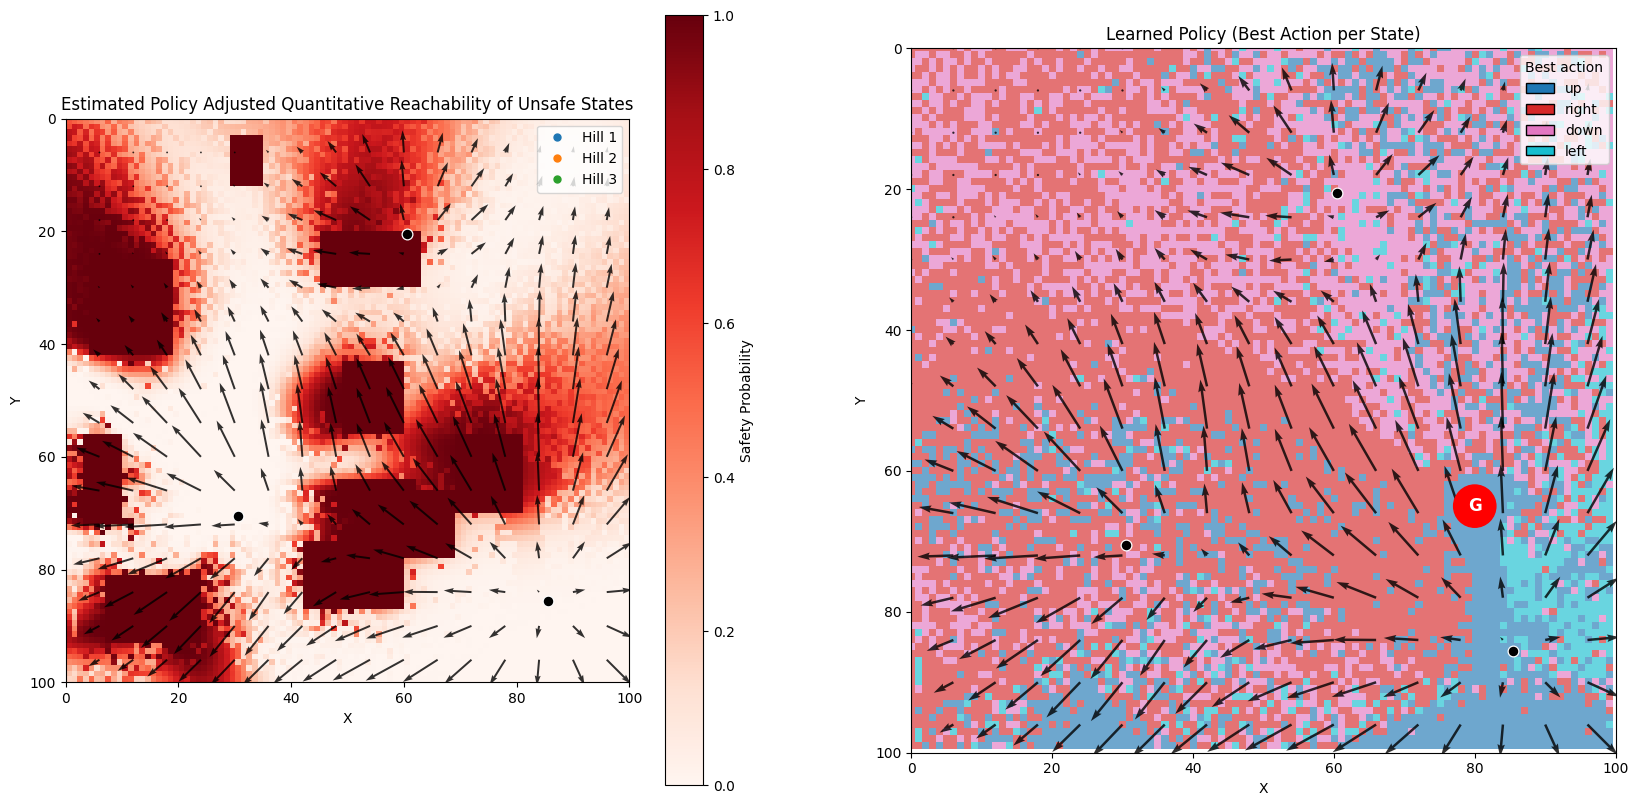

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
plot_safety_heatmap(unsafe_map, env, ax=axs[0])
axs[0].set_title('Estimated Policy Adjusted Quantitative Reachability of Unsafe States')
plot_policy(Q, env, ax=axs[1])
env.plot_unsafe_mask(ax=axs[1])
axs[1].set_title('Learned Policy (Best Action per State)')
plt.show()

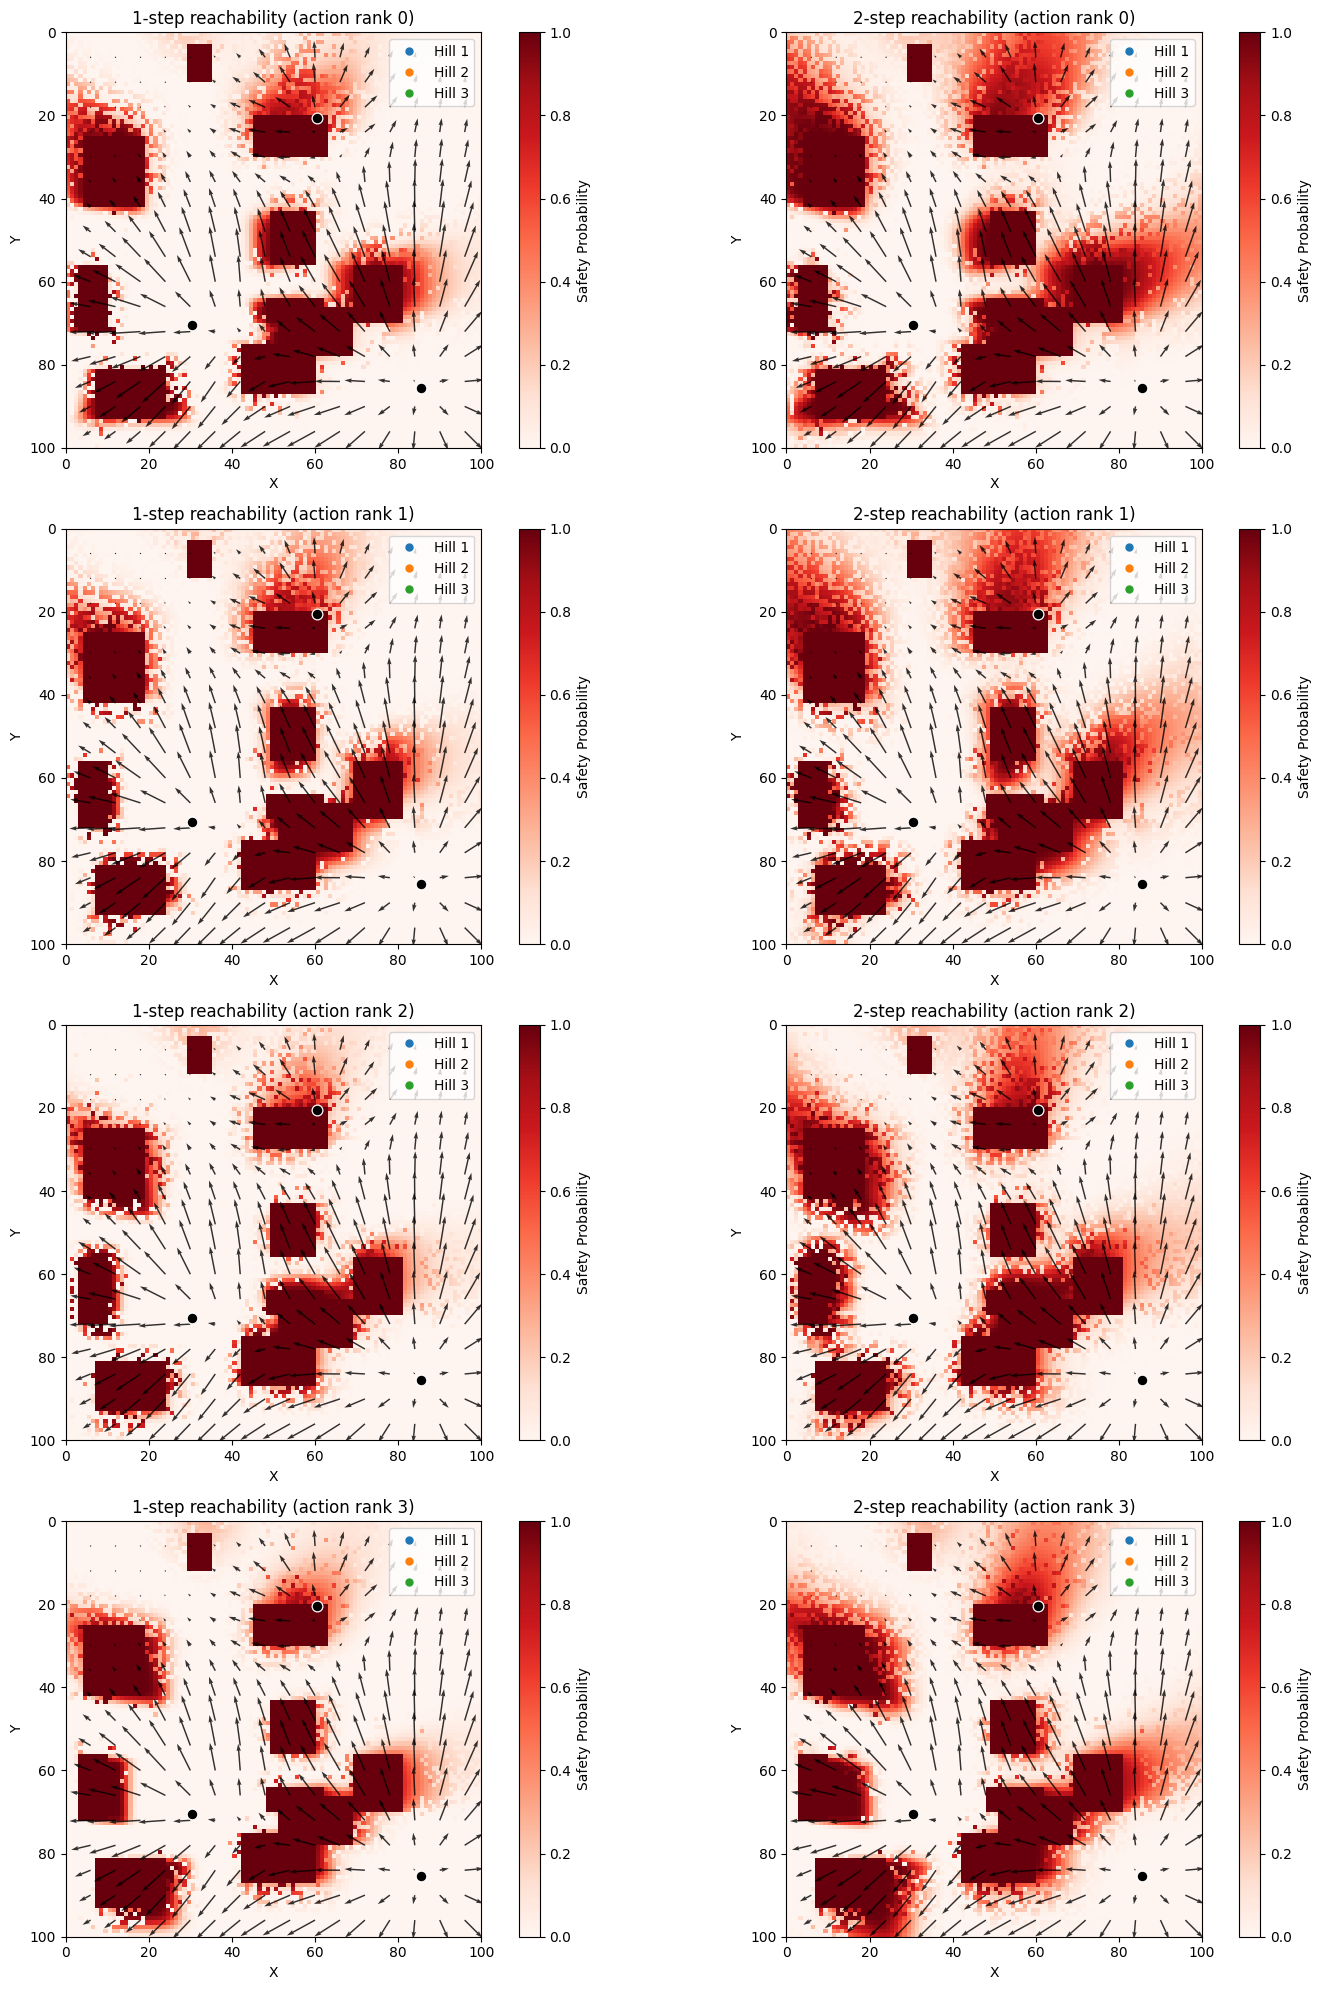

In [83]:
fig, ax = plt.subplots(4, 2, figsize=(15, 20))

reachability_maps = []

for i in range(len(actions)):
    pred_mean_with_policy, pred_cov_with_policy = policy_accounted_action_estimates(Q, model, actions, env=env, action_rank=i)
    A, b_ = calc_quantative_reachability_values(S, S_q, q, pred_mean_with_policy, pred_cov_with_policy, env=env)
    two_step = A @ b_

    unsafe_map_two_step = np.ones((max_x, max_y))
    unsafe_map_two_step[S_q[:, 0], S_q[:, 1]] = two_step + b_
    unsafe_map_one_step = np.ones((max_x, max_y))
    unsafe_map_one_step[S_q[:, 0], S_q[:, 1]] = b_

    plot_safety_heatmap(unsafe_map_one_step, env, ax=ax[i][0])
    ax[i][0].set_title(f'1-step reachability (action rank {i})')
    plot_safety_heatmap(unsafe_map_two_step, env, ax=ax[i][1])
    ax[i][1].set_title(f'2-step reachability (action rank {i})')

    reachability_maps.append((unsafe_map_one_step, unsafe_map_two_step))

plt.tight_layout()
plt.show()

In [109]:
steps_accounted = 1
reachability_maps = np.array(reachability_maps)
reachability_maps_step = reachability_maps[:, steps_accounted-1, :, :]
action_order = np.argsort(Q, axis=2)[:, :, ::-1]
reachability_maps_step = np.moveaxis(reachability_maps_step, 0, -1)
risk_per_action = np.take_along_axis(
    reachability_maps_step,
    action_order,
    axis=2
)

risk_aversions = np.arange(0, 400, 2)

def apply_risk(q, risk, risk_aversion):
    return q - (risk*10)**2 * risk_aversion

new_Qs = []

for delta in risk_aversions:
    new_Qs.append(apply_risk(Q, risk_per_action, delta))
    

Evaluating risk-adjusted policies: 100%|██████████| 200/200 [02:43<00:00,  1.22it/s]


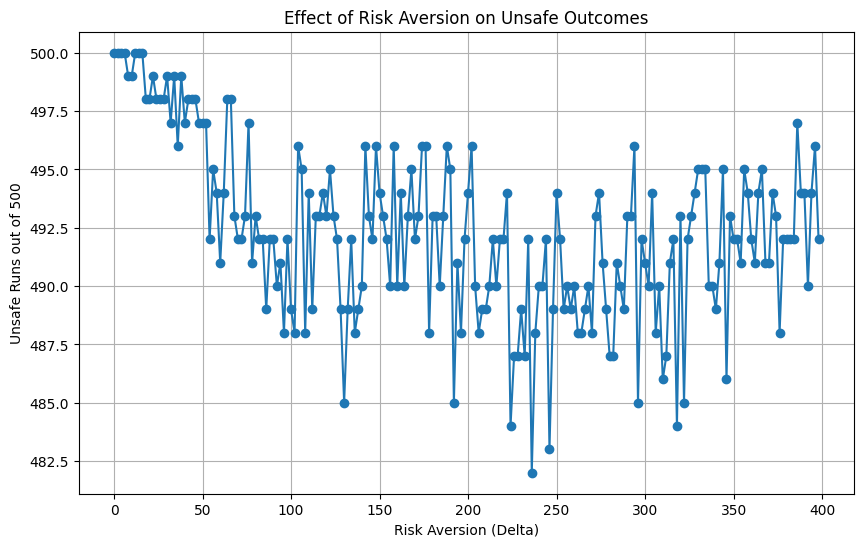

In [110]:
from tqdm import tqdm
RUNS_PER_Q = 500

start_state = (0, 0)

unsafe_counts = []

for i, new_Q in enumerate(tqdm(new_Qs, desc="Evaluating risk-adjusted policies")):
    unsafe_count = 0
    for run in range(RUNS_PER_Q):
        s = start_state
        for step in range(MAX_STEPS):
            x, y = s
            a_index = np.argmax(new_Q[x, y, :])
            a = list(actions.values())[a_index]
            s = env.transition(s, a)
            if env.unsafe_mask[s]:
                unsafe_count += 1
                break
    unsafe_counts.append(unsafe_count)

plt.figure(figsize=(10, 6))
plt.plot(risk_aversions, unsafe_counts, marker='o')
plt.xlabel('Risk Aversion (Delta)')
plt.ylabel(f'Unsafe Runs out of {RUNS_PER_Q}')
plt.title('Effect of Risk Aversion on Unsafe Outcomes')
plt.grid(True)
plt.show()


Evaluating risk-adjusted policies (normalized): 100%|██████████| 5/5 [04:34<00:00, 54.82s/it]


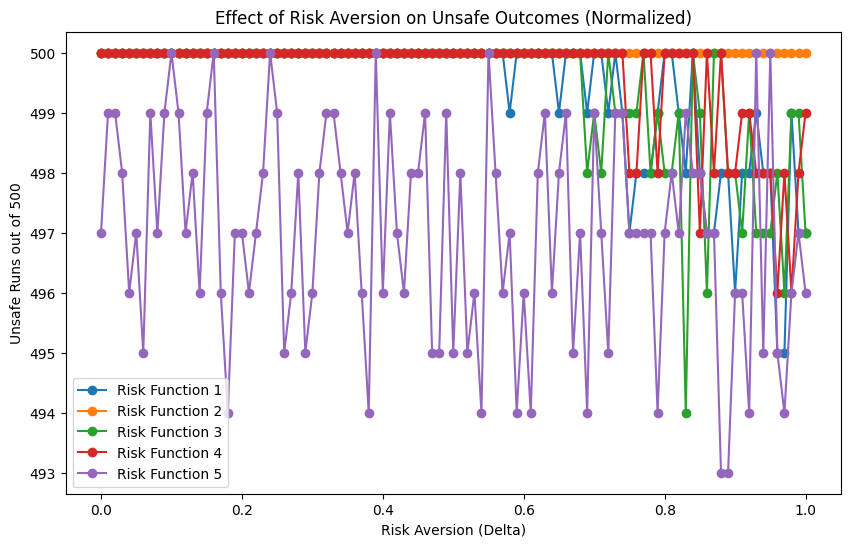

In [ ]:
norm_Q = (Q - Q.min()) / (Q.max() - Q.min())
risk_aversions_ = np.arange(0, 1.00001, 0.01)


new_Qs_ = []

risk_functions = [
    lambda q, risk, delta: q - risk * delta,           # linear
    lambda q, risk, delta: q - (risk * delta) ** 2,    # quadratic
    lambda q, risk, delta: q - (np.exp(risk * delta) - 1), # exponential
    lambda q, risk, delta: q - np.log1p(risk * delta),  # logarithmic
    lambda q, risk, delta: q + (delta-risk)  
    
]

for risk_func in risk_functions:  
    new_Qs_.append([risk_func(norm_Q, risk_per_action, delta) for delta in risk_aversions_])  


unsafe_counts_ = []
for i, new_Q in enumerate(tqdm(new_Qs_, desc="Evaluating risk-adjusted policies (normalized)")):
    unsafe_count = []
    for Q_ in new_Q:
        unsafe_fin = 0
        for run in range(RUNS_PER_Q):
            s = start_state
            for step in range(MAX_STEPS):
                x, y = s
                a_index = np.argmax(Q_[x, y, :])
                a = list(actions.values())[a_index]
                s = env.transition(s, a)
                if env.unsafe_mask[s]:
                    unsafe_fin += 1
                    break
        unsafe_count.append(unsafe_fin)
    unsafe_counts_.append(unsafe_count)

plt.figure(figsize=(10, 6))
for i, unsafe_count in enumerate(unsafe_counts_):
    plt.plot(risk_aversions_, unsafe_count, marker='o', label=f'Risk Function {i+1}')
plt.xlabel('Risk Aversion (Delta)')
plt.ylabel(f'Unsafe Runs out of {RUNS_PER_Q}')
plt.title('Effect of Risk Aversion on Unsafe Outcomes (Normalized)')
plt.legend()
plt.show()

/var/folders/rv/b01cr15x4v1d0l_0f9t176nr0000gn/T/ipykernel_34912/4267497286.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  action_cmap = plt.cm.get_cmap('tab10', 4)


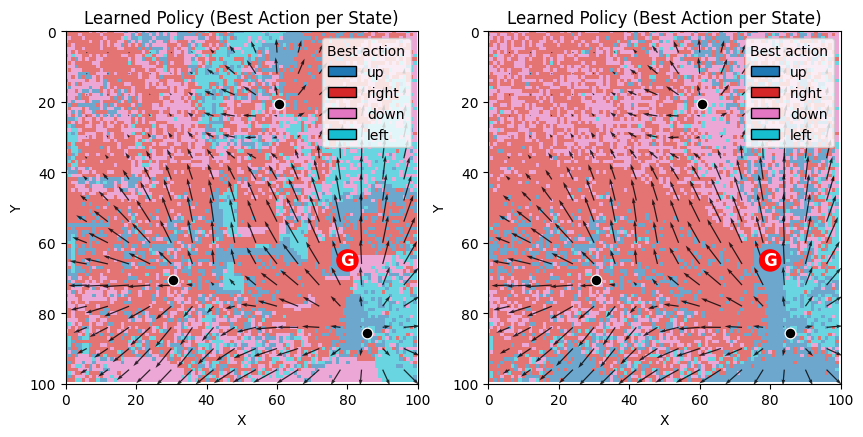

In [120]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8))

plot_policy(new_Qs[-1], env, ax=ax[0])
plot_policy(Q, env, ax=ax[1])
plt.show()